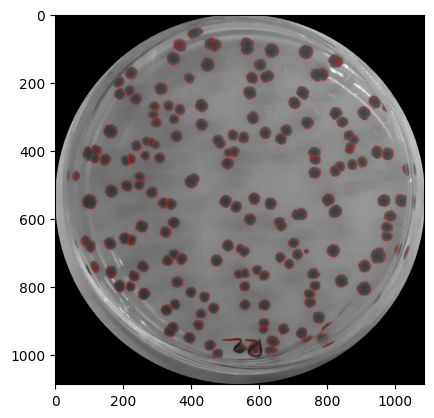

In [56]:
%matplotlib inline
from phase.main.timeseries import Timeseries
from phase.main.dish import Dish

import matplotlib.pyplot as plt
import os
from scipy import ndimage as ndi
from skimage.segmentation import watershed, find_boundaries
from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
from skimage.morphology import h_maxima
import numpy as np
import cv2 as cv

from tests.data import SAVE_PATH

DIR =  r"C:\Users\Piotr\Desktop\Uni\7. Semester\Thesis\experimental\PHASE\data\Saved\05.02.2026\dish_detection\07.02.2026-07.55.02_dish0.png"
PRE =  r"C:\Users\Piotr\Desktop\Uni\7. Semester\Thesis\experimental\PHASE\data\Saved\05.02.2026\preprocessed\07.02.2026-07.55.02_dish0.png"


img = cv.imread(DIR, cv.IMREAD_GRAYSCALE)
pre = cv.imread(PRE, cv.IMREAD_GRAYSCALE)

distance = ndi.distance_transform_edt(pre)

distance_smooth = gaussian_filter(distance, sigma=1)
h = 0.1
h_maxima_mask = h_maxima(distance_smooth, h)
markers, _ = ndi.label(h_maxima_mask)

labels = watershed(-distance, markers, mask=pre)

# get boundaries
boundaries = find_boundaries(labels, mode='outer')

# make a copy of original image in color
img_color = cv.cvtColor(img, cv.COLOR_GRAY2BGR)

# overlay boundaries in red
img_color[boundaries] = [255, 0, 0]  # red

# show with matplotlib
plt.imshow(img_color)
plt.show()